# Tugas 2 (Varian Outlier) — K-Means dengan Centroid Awal di Outlier

**Mata Kuliah:** Data Mining

## Deskripsi
Varian dari Tugas 2: seluruh alur K-Means dijalankan **sama persis**, tetapi **centroid awal sengaja diletakkan di titik OUTLIER / terjauh** — yaitu **P5 = (Age 47, Income 253)** dan **P9 = (Age 26, Income 18)** — bukan di P1, P2 yang dekat kerumunan data. Tujuannya melihat pengaruh pemilihan centroid awal terhadap hasil K-Means.

1. Hitung manual untuk **K = 2** dengan centroid awal di outlier (langkah per iterasi).
2. Hitung untuk **K = 3, 4, 5, 6** menggunakan program (k-means++).
3. Visualisasi **Elbow Method**.
4. Analisis kualitas klaster.

> Untuk perbandingan langsung **baseline (P1,P2) vs outlier (P5,P9)**, lihat `Tugas2_KMeans_Perbandingan_Centroid.ipynb`.

## 1. Library & Data

### Penjelasan kode

- Mengimpor `numpy`, `pandas`, `matplotlib`, serta `KMeans` dan `StandardScaler` dari **scikit-learn**.
- `np.random.seed(42)` agar hasil random (mis. inisialisasi K-Means) dapat direproduksi.
- DataFrame `data` berisi 10 pelanggan dengan dua atribut numerik: **Age** (umur) dan **Income** (penghasilan).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Data Pelanggan (sumber: tabel "Contoh Kasus: Klasterisasi Pelanggan")
# Atribut: Age (umur) dan Income
data = pd.DataFrame({
    'CustID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Age':    [41, 47, 33, 29, 47, 40, 38, 42, 26, 47],
    'Income': [19, 100, 57, 19, 253, 81, 56, 64, 18, 115],
})
data

,CustID,Age,Income
0,1,41,19
1,2,47,100
2,3,33,57
3,4,29,19
4,5,47,253
5,6,40,81
6,7,38,56
7,8,42,64
8,9,26,18
9,10,47,115


### Penjelasan kode

- `X = data[['Age', 'Income']].values` mengubah DataFrame menjadi `ndarray` shape (10, 2) untuk dipakai algoritma.
- Scatter plot menampilkan sebaran 10 pelanggan pada bidang Age × Income.
- Loop `annotate` menambahkan label `P1..P10` di samping setiap titik agar mudah dirujuk saat membahas hasil.

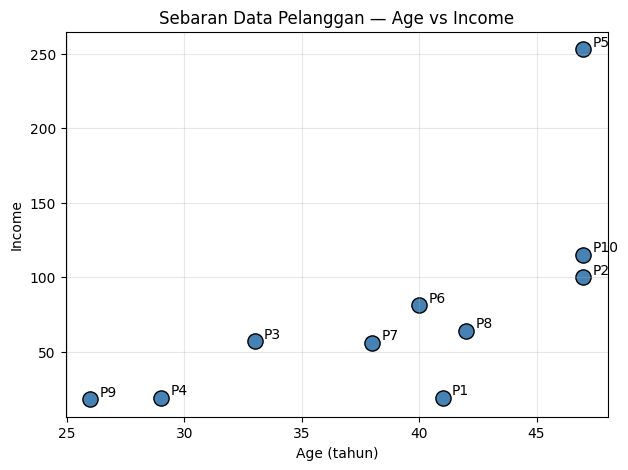

In [2]:
X = data[['Age', 'Income']].values

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=120, c='steelblue', edgecolors='k')
for i, row in data.iterrows():
    plt.annotate(f"P{row['CustID']}", (row['Age'] + 0.4, row['Income'] + 2))
plt.xlabel('Age (tahun)')
plt.ylabel('Income')
plt.title('Sebaran Data Pelanggan — Age vs Income')
plt.grid(alpha=0.3)
plt.show()

## 2. Hitung Manual untuk K = 2 (Centroid Awal di Outlier)

Berbeda dari Tugas 2 asli yang memakai C1 = P1 dan C2 = P2 (dekat data), di sini centroid awal **diletakkan di titik ekstrem/outlier**:
1. Pilih 2 centroid awal: **C1 = P5 = (47, 253)** (outlier income tinggi) dan **C2 = P9 = (26, 18)** (income terendah).
2. Hitung jarak Euclidean setiap titik ke kedua centroid.
3. Setiap titik di-assign ke centroid terdekat.
4. Update centroid = rata-rata anggota klaster.
5. Ulangi sampai centroid tidak berubah (konvergen).

Catatan: data dipakai **apa adanya (tanpa standarisasi)** sehingga **Income** (skala besar) mendominasi jarak — efek outlier jadi terlihat jelas.

### Penjelasan kode

Implementasi **manual** K-Means agar setiap iterasi terlihat:

- `euclid(a, b)` — jarak Euclidean dua titik: $\sqrt{\sum (a_i-b_i)^2}$.
- `kmeans_manual(X, centroids_awal, max_iter)`:
  1. **Assign** — setiap titik dilabeli ke centroid terdekat (`np.argmin`).
  2. **Update** — centroid baru = rata-rata anggota klaster.
  3. Konvergen jika centroid baru ≈ centroid lama (`np.allclose`).
  4. `history` menyimpan centroid & label tiap iterasi untuk ditampilkan.
- Centroid awal **diletakkan di outlier/titik terjauh**: **C1 = P5 = (47, 253)** dan **C2 = P9 = (26, 18)**.
- Output mencetak centroid dan label setiap iterasi sampai konvergen.

In [3]:
def euclid(a, b):
    return np.sqrt(np.sum((np.array(a) - np.array(b)) ** 2))

def kmeans_manual(X, centroids_awal, max_iter=20):
    centroids = np.array(centroids_awal, dtype=float)
    history = []
    for it in range(max_iter):
        # Step assign
        labels = []
        for x in X:
            jarak = [euclid(x, c) for c in centroids]
            labels.append(int(np.argmin(jarak)))
        labels = np.array(labels)
        history.append({'iter': it + 1, 'centroids': centroids.copy(), 'labels': labels.copy()})
        # Step update
        new_centroids = np.array([
            X[labels == k].mean(axis=0) if (labels == k).any() else centroids[k]
            for k in range(len(centroids))
        ])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, labels, history

# Centroid awal di OUTLIER / titik terjauh: P5=(47,253) dan P9=(26,18)
idx_outlier = [4, 8]   # indeks P5 dan P9
centroids_awal = [X[idx_outlier[0]], X[idx_outlier[1]]]
centroids2, labels2, hist2 = kmeans_manual(X, centroids_awal)

print(f'Konvergen setelah {len(hist2)} iterasi.')
for h in hist2:
    print(f"\nIterasi {h['iter']}:")
    print(f"  Centroid C1 = {np.round(h['centroids'][0], 2)}")
    print(f"  Centroid C2 = {np.round(h['centroids'][1], 2)}")
    print(f"  Label       = {h['labels']}")

Konvergen setelah 2 iterasi.

Iterasi 1:
  Centroid C1 = [ 47. 253.]
  Centroid C2 = [26. 18.]
  Label       = [1 1 1 1 0 1 1 1 1 1]

Iterasi 2:
  Centroid C1 = [ 47. 253.]
  Centroid C2 = [38.11 58.78]
  Label       = [1 1 1 1 0 1 1 1 1 1]


### Penjelasan kode

- Membangun tabel **jarak iterasi pertama** sesuai format perhitungan manual: setiap titik dihitung jaraknya ke C1 dan C2, lalu kolom `Klaster` menunjukkan ke centroid mana titik tersebut di-assign.
- Tabel ini berguna untuk dilampirkan sebagai bukti hitungan tangan.

In [4]:
# Tabel jarak iterasi pertama (untuk perhitungan manual yang dilampirkan)
c1, c2 = centroids_awal
tabel = []
for i, x in enumerate(X):
    d1 = euclid(x, c1)
    d2 = euclid(x, c2)
    tabel.append({
        'CustID': i + 1,
        'Age': x[0],
        'Income': x[1],
        f'Jarak ke C1{tuple(c1)}': round(d1, 3),
        f'Jarak ke C2{tuple(c2)}': round(d2, 3),
        'Klaster': 1 if d1 < d2 else 2,
    })
pd.DataFrame(tabel)

,CustID,Age,Income,"Jarak ke C1(np.int64(47), np.int64(253))","Jarak ke C2(np.int64(26), np.int64(18))",Klaster
0,1,41,19,234.077,15.033,2
1,2,47,100,153.000,84.646,2
2,3,33,57,196.499,39.623,2
3,4,29,19,234.691,3.162,2
4,5,47,253,0.000,235.936,1
5,6,40,81,172.142,64.537,2
6,7,38,56,197.205,39.850,2
7,8,42,64,189.066,48.703,2
8,9,26,18,235.936,0.000,2
9,10,47,115,138.000,99.247,2


### Penjelasan kode

- Scatter plot hasil **akhir** K-Means manual dengan K=2:
  - Titik diwarnai sesuai klaster (`labels2`).
  - Centroid ditandai `X` hitam besar.
- Visualisasi ini memperlihatkan pemisahan kelompok income rendah vs income tinggi.

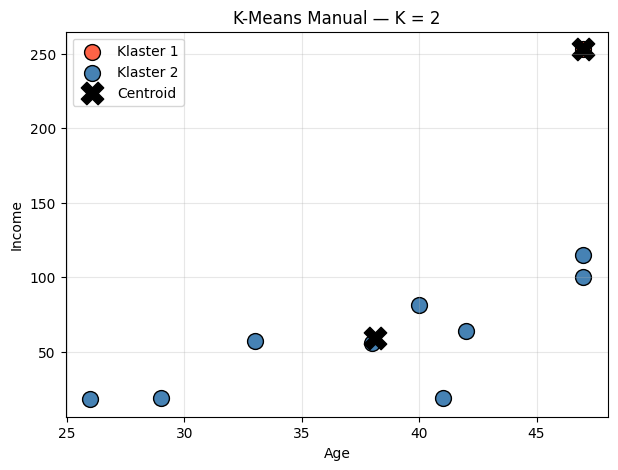

In [5]:
# Visualisasi hasil akhir K=2
plt.figure(figsize=(7, 5))
warna = ['tomato', 'steelblue']
for k in range(2):
    pts = X[labels2 == k]
    plt.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=130, edgecolors='k', label=f'Klaster {k+1}')
plt.scatter(centroids2[:, 0], centroids2[:, 1], marker='X', s=260, c='black', label='Centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('K-Means Manual — K = 2')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Visualisasi Tiap Iterasi (centroid awal **outlier P5, P9**)

Menampilkan keadaan klaster di setiap iterasi sampai konvergen. ✖ = centroid yang dipakai pada iterasi itu. Bandingkan dengan versi baseline di `Tugas2_KMeans_Elbow.ipynb`.

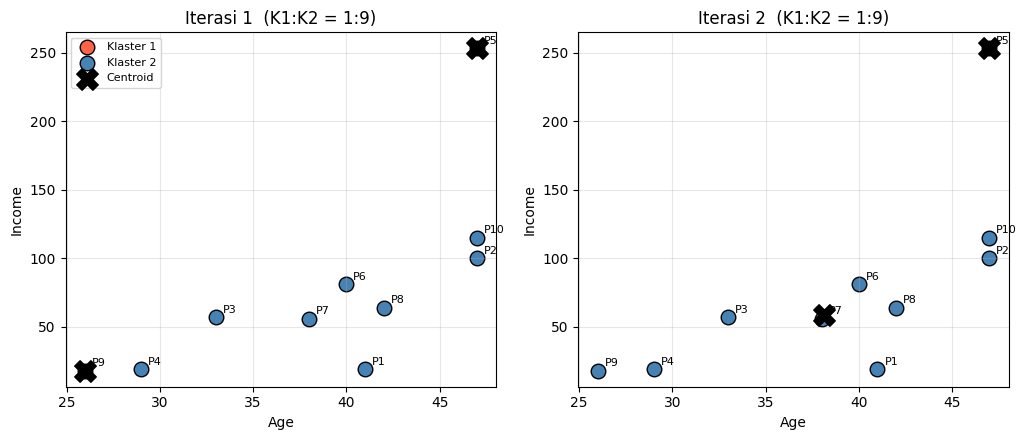

In [6]:
# Visualisasi K-Means manual TIAP ITERASI (langkah demi langkah)
label_titik = [f'P{i+1}' for i in range(len(X))]
n = len(hist2)
fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.5))
if n == 1:
    axes = [axes]
warna = ['tomato', 'steelblue']
for t, (ax, h) in enumerate(zip(axes, hist2)):
    cen, lab = h['centroids'], h['labels']
    for k in range(2):
        pts = X[lab == k]
        ax.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=110, edgecolors='k', label=f'Klaster {k+1}')
    ax.scatter(cen[:, 0], cen[:, 1], marker='X', s=240, c='black', zorder=5, label='Centroid')
    for i, x in enumerate(X):
        ax.annotate(label_titik[i], (x[0], x[1]), textcoords='offset points', xytext=(5, 3), fontsize=8)
    jml = [int((lab == 0).sum()), int((lab == 1).sum())]
    ax.set_title(f'Iterasi {t+1}  (K1:K2 = {jml[0]}:{jml[1]})')
    ax.set_xlabel('Age'); ax.set_ylabel('Income'); ax.grid(alpha=0.3)
    if t == 0:
        ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. K-Means Programatik untuk K = 3, 4, 5, 6

Karena skala `Age` (puluhan) dan `Income` (sampai 250+) sangat berbeda, dilakukan **standarisasi** terlebih dahulu agar jarak Euclidean tidak didominasi oleh Income. SSE/Inertia juga dilaporkan dalam ruang asli untuk interpretasi yang lebih mudah.

### Penjelasan kode

- `StandardScaler` melakukan **z-score normalization** ($z = (x-\mu)/\sigma$). Penting karena Income (puluhan–ratusan) jauh lebih besar daripada Age, sehingga tanpa standarisasi jarak Euclidean akan didominasi Income.
- Loop `k` = 2..6: fit `KMeans` pada data ter-standarisasi (`n_init=10` untuk menghindari local minimum, `random_state=42` untuk reprodusibilitas).
- Centroid dikembalikan ke skala asli (`scaler.inverse_transform`) supaya SSE bisa juga dihitung di **ruang asli** → lebih intuitif untuk interpretasi.
- Kedua nilai SSE dicetak per K.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

hasil = {}
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    # SSE pada ruang asli
    centers_asli = scaler.inverse_transform(km.cluster_centers_)
    sse_asli = sum(euclid(X[i], centers_asli[km.labels_[i]]) ** 2 for i in range(len(X)))
    hasil[k] = {
        'model': km,
        'labels': km.labels_,
        'centers_asli': centers_asli,
        'sse_scaled': km.inertia_,
        'sse_asli': sse_asli,
    }
    print(f'K={k}  SSE(scaled)={km.inertia_:.4f}   SSE(asli)={sse_asli:.2f}')

K=2  SSE(scaled)=8.7699   SSE(asli)=18466.57
K=3  SSE(scaled)=3.3855   SSE(asli)=6924.33
K=4  SSE(scaled)=1.3670   SSE(asli)=3188.58
K=5  SSE(scaled)=0.7494   SSE(asli)=2180.25
K=6  SSE(scaled)=0.3435   SSE(asli)=451.50


### Penjelasan kode

- Menggandeng kolom `K=2..K=6` ke `df_label` sehingga bisa dibandingkan label tiap pelanggan untuk setiap nilai K.
- Berguna untuk melihat bagaimana titik berpindah klaster ketika K diubah (mis. P5 dengan income 253 sering jadi klaster sendirian).

In [8]:
# Tampilkan label per K
df_label = data[['CustID', 'Age', 'Income']].copy()
for k in [2, 3, 4, 5, 6]:
    df_label[f'K={k}'] = hasil[k]['labels']
df_label

,CustID,Age,Income,K=2,K=3,K=4,K=5,K=6
0,1,41,19,0,0,2,3,2
1,2,47,100,1,0,1,1,1
2,3,33,57,0,1,0,0,5
3,4,29,19,0,1,0,4,0
4,5,47,253,1,2,3,2,3
5,6,40,81,0,0,2,3,4
6,7,38,56,0,0,2,3,4
7,8,42,64,0,0,2,3,4
8,9,26,18,0,1,0,4,0
9,10,47,115,1,0,1,1,1


## 4. Visualisasi Klaster K = 3..6

### Penjelasan kode

- Subplot 2×2 untuk K = 3, 4, 5, 6.
- Tiap subplot: titik diwarnai per klaster (colormap `tab10`), centroid berupa `X` hitam.
- Judul subplot menampilkan SSE pada ruang asli sehingga bisa dibandingkan langsung antar K.

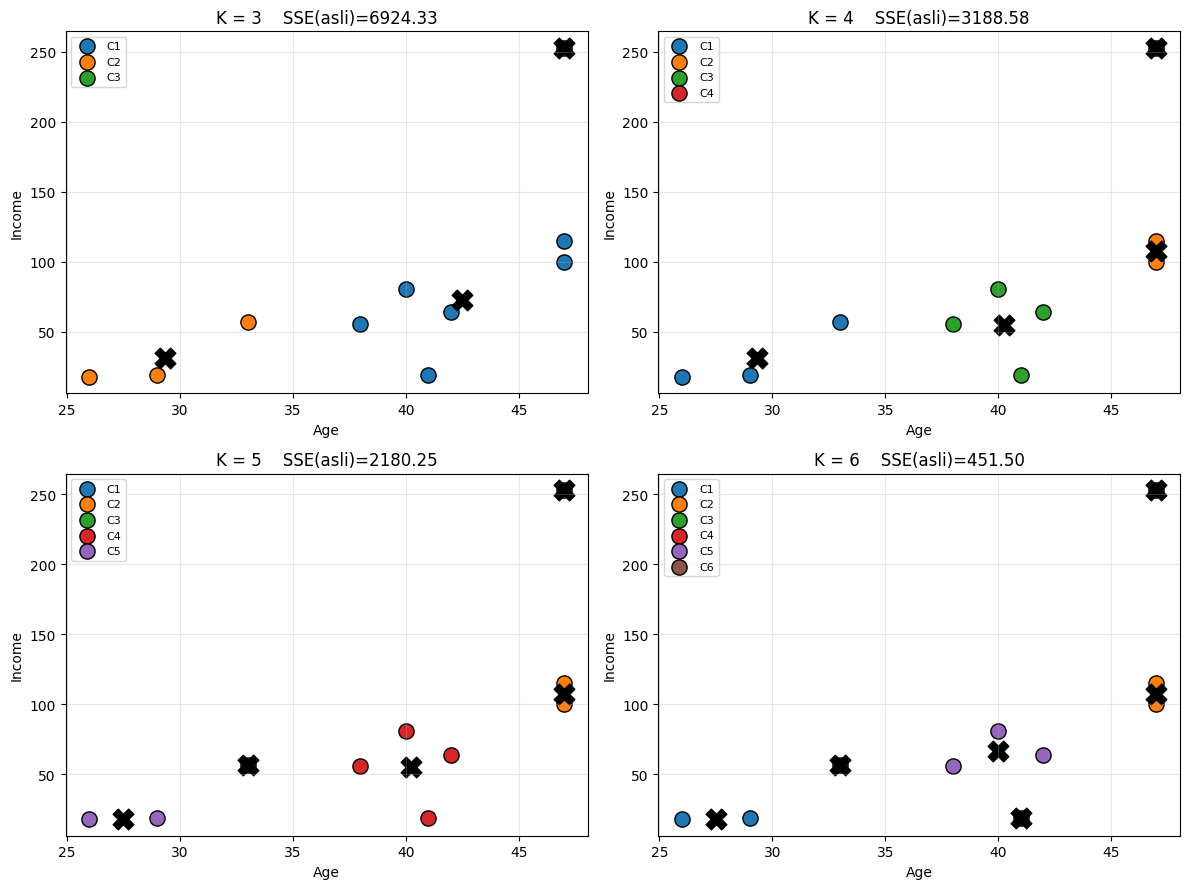

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
for ax, k in zip(axs.flatten(), [3, 4, 5, 6]):
    labels = hasil[k]['labels']
    centers = hasil[k]['centers_asli']
    cmap = plt.get_cmap('tab10')
    for c in range(k):
        pts = X[labels == c]
        ax.scatter(pts[:, 0], pts[:, 1], color=cmap(c), s=120, edgecolors='k', label=f'C{c+1}')
    ax.scatter(centers[:, 0], centers[:, 1], marker='X', c='black', s=220)
    ax.set_title(f'K = {k}    SSE(asli)={hasil[k]["sse_asli"]:.2f}')
    ax.set_xlabel('Age'); ax.set_ylabel('Income')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Elbow Method

### Penjelasan kode

**Elbow Method** — heuristik untuk memilih K optimal:

- Hitung SSE/Inertia untuk K = 1..7.
- Plot kurva K vs SSE → bentuk **siku/elbow** menandakan titik di mana penambahan K sudah tidak banyak menurunkan SSE.
- Dicetak juga `Δ SSE` antar K berturutan; **K dengan Δ besar** lalu disusul Δ kecil = kandidat siku.

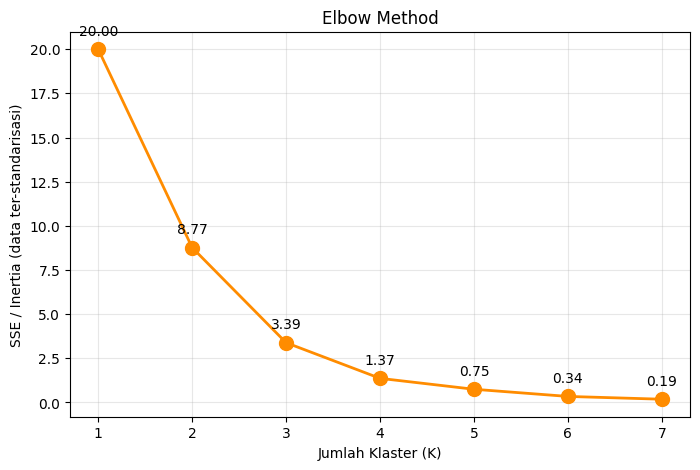

Δ SSE saat K=2: 11.2301
Δ SSE saat K=3: 5.3843
Δ SSE saat K=4: 2.0185
Δ SSE saat K=5: 0.6176
Δ SSE saat K=6: 0.4059
Δ SSE saat K=7: 0.1583


In [10]:
K_range = list(range(1, 8))
sse_list = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    sse_list.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, sse_list, 'o-', linewidth=2, markersize=10, color='darkorange')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('SSE / Inertia (data ter-standarisasi)')
plt.title('Elbow Method')
plt.grid(alpha=0.3)
for k, s in zip(K_range, sse_list):
    plt.annotate(f'{s:.2f}', (k, s), textcoords='offset points', xytext=(0, 10), ha='center')
plt.show()

# Hitung 'siku' otomatis: titik dengan penurunan delta paling tajam
deltas = [sse_list[i-1] - sse_list[i] for i in range(1, len(sse_list))]
for k, d in zip(K_range[1:], deltas):
    print(f'Δ SSE saat K={k}: {d:.4f}')

## 6. Analisis Kualitas Klaster

Cara membaca grafik:
- **K = 1** → semua titik dalam satu klaster, SSE paling besar.
- Saat K bertambah, SSE turun karena titik makin dekat ke centroid masing-masing.
- Pada **siku (elbow)**, penurunan SSE mulai melandai → menambah K tidak banyak menambah informasi.
- Titik siku itulah yang dipilih sebagai **K optimal**.

Untuk dataset pelanggan ini (10 record, atribut Age & Income), elbow umumnya muncul di **K = 2** atau **K = 3** — silakan baca dari grafik & tabel Δ SSE di atas.

Indikasi kualitatif:
- **K = 2** → memisahkan kelompok income rendah vs income tinggi (sesuai contoh kasus pada slide).
- **K = 3** → muncul kelompok income menengah → biasanya kompromi terbaik.
- **K ≥ 5** → klaster mulai berisi 1–2 anggota saja (over-segmentasi); P5 (income 253) cenderung jadi outlier sendirian.

## 7. Kesimpulan (Varian Outlier)

1. Dengan centroid awal di **outlier (P5, P9)**, K-Means manual K=2 **konvergen sangat cepat (2 iterasi)** tetapi hasilnya **buruk**: outlier **P5 menjadi klaster sendirian** dan 9 titik lain menumpuk di satu klaster (pembagian **1 : 9**).
2. Bandingkan dengan Tugas 2 asli (centroid awal P1, P2 dekat data) yang menghasilkan pembagian **7 : 3** yang lebih masuk akal — artinya **anggota klaster berubah total** hanya karena centroid awal berbeda.
3. Ini membuktikan K-Means **sensitif terhadap inisialisasi centroid dan terhadap outlier**, terutama bila data **tidak distandarisasi** (Income mendominasi jarak).
4. Praktik baik: **standarisasi (StandardScaler)** + **k-means++** + **`n_init` banyak** agar tidak terjebak inisialisasi buruk (lihat Section 3 yang memakai sklearn).